## Hammerstein-Wiener model identification example: thermal behavior of a DC-motor

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchdiffeq import odeint
from scipy.integrate import solve_ivp



We start our investigation with building a simple baseline model. Our (known) inputs are
$$u(t) = \begin{bmatrix}i(t) \\\\ n(t)\end{bmatrix}$$
with $i(t)$ being the electric motor current and $n(t)$ being the motor rotational speed. Moreover, we consider a simple loss model
$$P_\mathrm{v}(u(t), \vartheta(t)) = R_\mathrm{Cu}(\vartheta(t))\cdot i^2(t) + \frac{(L\,i(t)\,n(t)\,\frac{2\pi}{60})^2}{R_\mathrm{Fe}(\vartheta(t))}$$
with $R_\mathrm{Cu}$ being the ohmic resistance, $R_\mathrm{Fe}$ an equivalent iron loss resistance, $L$ the inductance and $\vartheta(t)$ the lumped temperature of the DC-motor (the model's state $x(t)$). The temperature dynamics are governed by a scalar ODE:
$$\frac{\mathrm{d}}{\mathrm{d}t}x(t) = \frac{1}{C_\mathrm{Th}}\left(\frac{\vartheta_\mathrm{A}(t)-x(t)}{R_\mathrm{Th}} + P_\mathrm{v}(u(t), x(t))\right).$$

The loss $P_\mathrm{v}(t)$ has a **nonlinear** dependence on the inputs $i(t)$ and $n(t)$, making this a **Hammerstein model** example.


### Ground truth model

In [3]:
# True input signals (time-dependent functions)
i_signal  = lambda t: 125 + 50*np.sin(2*np.pi*t/60)   + 60*np.sin(2*np.pi*t/300)
n_signal  = lambda t: 1000 + 100*np.cos(2*np.pi*t/100) + 500*np.cos(2*np.pi*t/1000)
ϑ_A       = lambda t: 20   + 2*np.sin(2*np.pi*t/2000)

# True parameters
R_Cu0  = 0.016    # copper resistance at 20 °C  [Ω]
α_Cu   = 0.0039   # temperature coefficient of copper  [1/K]
R_Fe0  = 5000.0   # iron loss resistance at 20 °C  [Ω]
α_Fe   = 0.00651  # temperature coefficient of iron resistance  [1/K]
L      = 0.05     # inductance  [H]
C_Th   = 1400.0   # thermal capacitance  [J/K]
R_Th   = 0.17     # thermal resistance  [K/W]

def motor_ode(t, x):
    """Ground-truth DC-motor temperature ODE."""
    theta = x[0]
    R_Cu = R_Cu0 * (1 + α_Cu * (theta - 20))
    R_Fe = R_Fe0 * (1 + α_Fe * (theta - 20))
    i_t  = i_signal(t)
    n_t  = n_signal(t)
    Pv   = i_t**2 * R_Cu + (L * i_t * n_t / 60 * 2 * np.pi)**2 / R_Fe
    dxdt = (1 / C_Th) * ((-theta + ϑ_A(t)) / R_Th + Pv)
    return [dxdt]


Next, we generate ground truth data including mild temperature sensor noise.

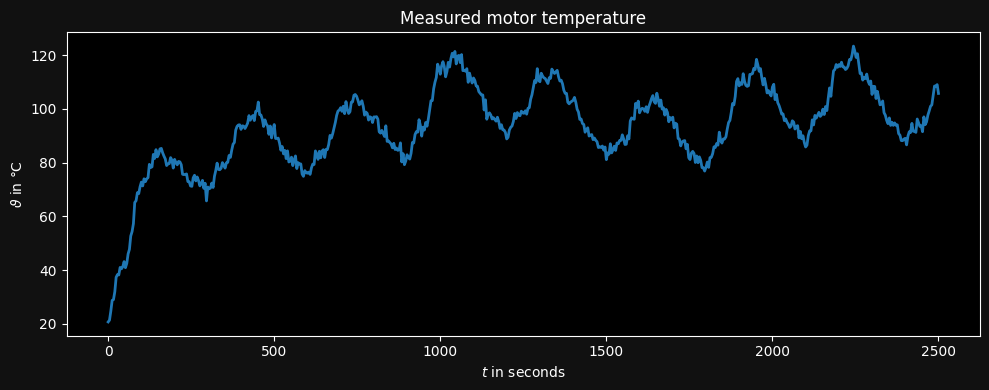

In [4]:
x0     = [20.0]          # initial temperature [°C]
dt     = 4.0             # sampling time [s]
t_end  = 2500.0
tspan  = (0.0, t_end)
tsteps = np.arange(0.0, t_end + dt, dt, dtype=np.float32)

sol = solve_ivp(motor_ode, tspan, x0, method='RK45', t_eval=tsteps, max_step=dt)
t = sol.t
x = sol.y[0]

np.random.seed(42)
y = x + 1.5 * np.random.randn(len(x))   # noisy measurement

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y, linewidth=2, label="Measured temperature")
ax.set_title("Measured motor temperature")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$\vartheta$ in °C")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout(); plt.show()



### Preparation of a neural ODE (NODE) style Hammerstein model identification

For the following identification process, we make the following assumption: $$\frac{\mathrm{d}}{\mathrm{d}t}\hat{x}(t)= \frac{1}{\hat{C}_\mathrm{Th}}\left(\frac{\vartheta_\mathrm{A}(t)-x(t)}{\hat{R}_\mathrm{Th}} + \hat{P}_{\mathrm{v}, w_{\mathrm{ANN}}}(u(t))\right).$$

Hence, we assume that we have some structural pre-knowledge on the ODE, however, we do lack detailed information on the nonlinear (static) loss inputs which is why we will make use of an artificial neural network approximation $\hat{P}_{\mathrm{v}, w_{\mathrm{ANN}}}(u(t), x(t))$. Also, the thermal parameters of the ODE are not exactly known to us and require identification.   

In order to identify the above temperature dynamics we start with defining some NODE simulation parameters.

We assume the following partially known ODE structure:
$$\frac{\mathrm{d}}{\mathrm{d}t}\hat{x}(t)= \frac{1}{\hat{C}_\mathrm{Th}}\left(\frac{\vartheta_\mathrm{A}(t)-x(t)}{\hat{R}_\mathrm{Th}} + \hat{P}_{\mathrm{v},w_\mathrm{ANN}}(u(t), x(t))\right).$$

The thermal parameters $\{\hat{R}_\mathrm{Th}, \hat{C}_\mathrm{Th}\}$ are **unknown** and identified jointly with the power-loss ANN $\hat{P}_{\mathrm{v},w_\mathrm{ANN}}$.


In [12]:
x0_NODE   = np.float32(y[0])
tspan_NODE = (np.float32(0.0), np.float32(t_end))
datasize   = int(t_end / dt + 1)
tsteps_NODE = np.linspace(tspan_NODE[0], tspan_NODE[1], datasize, dtype=np.float32)
tsteps_tensor = torch.tensor(tsteps_NODE)


We set up an ANN with **three inputs** (normalised current², normalised (i·n)², normalised temperature) and a **single output** (power loss). A `sigmoid` output activation ensures the predicted loss is always non-negative (physically meaningful) (priori knowledge).


In [6]:
torch.manual_seed(260787)

ann_loss = nn.Sequential(
    nn.Linear(3, 10),
    nn.Tanh(),
    nn.Linear(10, 1),
    nn.Sigmoid(),          # ensures non-negative power loss output
)


To normalize the inputs into the power loss ANN we calculate the max values such that the inputs are in the range [-1,1]. Furthermore, based on a very limited pre-knowledge about motor losses we know that the losses are temperature-dependent and will depend also on the squared motor current and squared product of the motor speed and current.

We normalise ANN inputs to [-1, 1] using the maximum values observed in the data.

In [ ]:
y_max      = float(np.max(y))
i_sqr_max  = float(np.max([i_signal(t_)**2          for t_ in tsteps_NODE]))
in_sqr_max = float(np.max([(i_signal(t_)*n_signal(t_))**2 for t_ in tsteps_NODE]))

# Initial guesses for scaling factors - scaling factors are also identified when determining the nonlinear static model for the inputs to solve the dynamics
C_th_guess = 2000.0    # ~50 % off from truth (1400 J/K)
R_th_guess = 0.10      # ~50 % off from truth (0.17 K/W)
P_v_guess  = 5000.0    # rough estimate of max. power loss [W]

print(f"y_max={y_max:.2f} °C | i²_max={i_sqr_max:.1f} A² | (i·n)²_max={in_sqr_max:.3e}")


y_max=123.38 °C | i²_max=55090.2 A² | (i·n)²_max=1.241e+11


We build the NODE, jointly optimising thermal scale factors and ANN weights.

In [8]:
class HammersteinNODE(nn.Module):
    """
    Hammerstein-structured NODE for DC-motor temperature.
    States  : x = [theta]  (lumped motor temperature)
    Inputs  : i(t), n(t), ϑ_A(t)  — provided via closures over numpy functions
    Learnable: C_th_scale, R_th_scale, ANN weights
    """
    def __init__(self):
        super().__init__()
        self.log_C_th_scale = nn.Parameter(torch.tensor(0.0))   # exp(0) = 1 → starts at guess
        self.log_R_th_scale = nn.Parameter(torch.tensor(0.0))
        self.ann = ann_loss

    def forward(self, t, x):
        # x shape: (1,)  — single lumped temperature state
        theta = x[0]
        t_val = float(t)

        C_th_scale = torch.exp(self.log_C_th_scale)
        R_th_scale = torch.exp(self.log_R_th_scale)

        # Normalised ANN inputs
        feat = torch.stack([
            theta / y_max,
            torch.tensor(float(i_signal(t_val)**2      / i_sqr_max),  dtype=torch.float32),
            torch.tensor(float((i_signal(t_val)*n_signal(t_val))**2 / in_sqr_max), dtype=torch.float32),
        ]).unsqueeze(0)                                    # (1, 3)

        Pv    = P_v_guess * self.ann(feat)[0, 0]          # scalar tensor

        theta_A = torch.tensor(float(ϑ_A(t_val)), dtype=torch.float32)
        dxdt  = (1.0 / (C_th_scale * C_th_guess)) * (
                    (-theta + theta_A) / (R_th_scale * R_th_guess) + Pv
                )
        return dxdt.unsqueeze(0)                           # (1,)

model = HammersteinNODE()


Set up predict and loss functions.

In [10]:
y_tensor  = torch.tensor(y, dtype=torch.float32)
x0_tensor = torch.tensor([float(y[0])], dtype=torch.float32)

def predict_NODE():
    """Integrate the NODE over the full time horizon."""
    return odeint(model, x0_tensor, tsteps_tensor, method='rk4',
                  options={'step_size': float(dt)})[:, 0]   # (T,)

def loss_NODE():
    pred = predict_NODE()
    return torch.sum((y_tensor - pred) ** 2)


Train using Adam (1 000 iterations), matching the original Julia setup.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
losses = []

print("Training Hammerstein NODE...")
for iteration in range(1, 1001):
    optimizer.zero_grad()
    loss = loss_NODE()
    loss.backward()
    optimizer.step()
    losses.append(float(loss))
    if iteration % 50 == 0:
        C_sc = float(torch.exp(model.log_C_th_scale))
        R_sc = float(torch.exp(model.log_R_th_scale))
        print(f"  iter {iteration:4d} | loss={loss.item():.2f} "
              f"| Ĉ_Th={C_sc*C_th_guess:.0f} J/K | R̂_Th={R_sc*R_th_guess:.4f} K/W")

print("\nTrue values:  C_Th=1400 J/K | R_Th=0.17 K/W")


Training Hammerstein NODE...


C:\Users\27abd\AppData\Local\Temp\ipykernel_17000\648348353.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  losses.append(float(loss))


  iter   50 | loss=53045.94 | Ĉ_Th=2851 J/K | R̂_Th=0.0720 K/W
  iter  100 | loss=38378.93 | Ĉ_Th=2951 J/K | R̂_Th=0.0712 K/W
  iter  150 | loss=26813.96 | Ĉ_Th=3260 J/K | R̂_Th=0.0709 K/W
  iter  200 | loss=19601.90 | Ĉ_Th=3782 J/K | R̂_Th=0.0709 K/W
  iter  250 | loss=15023.89 | Ĉ_Th=4216 J/K | R̂_Th=0.0707 K/W
  iter  300 | loss=11912.47 | Ĉ_Th=4493 J/K | R̂_Th=0.0704 K/W
  iter  350 | loss=9497.72 | Ĉ_Th=4662 J/K | R̂_Th=0.0700 K/W
  iter  400 | loss=7593.94 | Ĉ_Th=4770 J/K | R̂_Th=0.0695 K/W
  iter  450 | loss=6167.56 | Ĉ_Th=4845 J/K | R̂_Th=0.0691 K/W
  iter  500 | loss=5125.75 | Ĉ_Th=4897 J/K | R̂_Th=0.0688 K/W
  iter  550 | loss=4355.57 | Ĉ_Th=4933 J/K | R̂_Th=0.0684 K/W
  iter  600 | loss=3772.00 | Ĉ_Th=4954 J/K | R̂_Th=0.0682 K/W
  iter  650 | loss=3320.13 | Ĉ_Th=4963 J/K | R̂_Th=0.0679 K/W
  iter  700 | loss=2964.75 | Ĉ_Th=4963 J/K | R̂_Th=0.0677 K/W
  iter  750 | loss=2682.55 | Ĉ_Th=4954 J/K | R̂_Th=0.0675 K/W
  iter  800 | loss=2457.36 | Ĉ_Th=4940 J/K | R̂_Th=0.0673 K/W
  

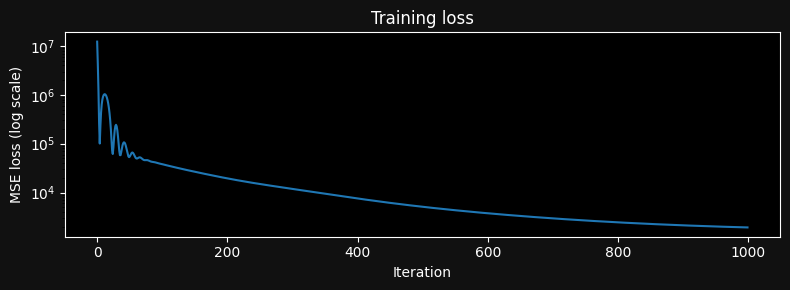

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(losses)
ax.set_title("Training loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE loss (log scale)")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout(); plt.show()


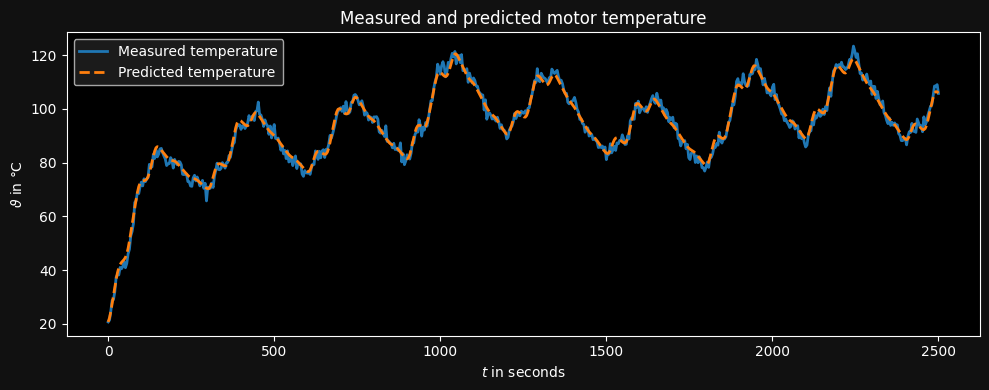

In [14]:
with torch.no_grad():
    pred = predict_NODE().numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps_NODE, y,    linewidth=2, label="Measured temperature")
ax.plot(tsteps_NODE, pred, linewidth=2, label="Predicted temperature", linestyle='--')
ax.set_title("Measured and predicted motor temperature")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$\vartheta$ in °C")
ax.legend(loc="upper left", facecolor="#222222", labelcolor="white")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout(); plt.show()


In [15]:
C_sc = float(torch.exp(model.log_C_th_scale))
R_sc = float(torch.exp(model.log_R_th_scale))
print("Identified thermal parameters:")
print(f"  Ĉ_Th = {C_sc*C_th_guess:.1f} J/K   (true: 1400 J/K)")
print(f"  R̂_Th = {R_sc*R_th_guess:.4f} K/W  (true: 0.17 K/W)")


Identified thermal parameters:
  Ĉ_Th = 4844.8 J/K   (true: 1400 J/K)
  R̂_Th = 0.0668 K/W  (true: 0.17 K/W)


Although the model accuracy in terms of the predicted vs. measured temperature profiles is quite satisfactory, the found parameters $\{\hat{R}_\mathrm{Th}, \hat{C}_\mathrm{Th}\}$ may be quite off from the true values:

- $R_\mathrm{Th}=0.17$ K/W  vs.  $\hat{R}_\mathrm{Th}\approx 0.06$ K/W
- $C_\mathrm{Th}=1.4$ kJ/K  vs.  $\hat{C}_\mathrm{Th}\approx 5$ kJ/K

The flexibility of the power-loss ANN compensates for inaccurate thermal parameters.

## Takeaway

**Physically-inspired NODE models (Hammerstein approach) can be very accurate in terms of prediction performance, while the static nonlinearity can lead to multiple local minima in the cost space — strong physical interpretability of the found parameters is therefore not guaranteed.**
